In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/advertising-sales-dataset/Advertising Budget and Sales.csv


In [2]:
#Loading libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings("ignore")

In [3]:
#Data Understanding
##Data Collection
df=pd.read_csv('/kaggle/input/advertising-sales-dataset/Advertising Budget and Sales.csv')
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df_n = df.drop(columns='Unnamed: 0')

In [6]:
df_n['total_spend']=df['TV Ad Budget ($)']+df['Radio Ad Budget ($)']+df['Newspaper Ad Budget ($)']
df_n.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($),total_spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0


In [7]:
df_n.drop(columns=['TV Ad Budget ($)','Radio Ad Budget ($)','Newspaper Ad Budget ($)'],inplace=True)
df_n.head()

,Sales ($),total_spend
0,22.1,337.1
1,10.4,128.9
2,9.3,132.4
3,18.5,251.3
4,12.9,250.0


#Data Preprocessing
##Exploratory Data Analysis(EDA)
- On the basis of this data, how should you spend advertising money in the future? These general questions might lead you to more specific questions:
    1. Is there a relationship between ads and sales?
    2. How strong is that relationship?
    3. Given ad spending, can sales be predicted?

In [8]:
df_n.describe()

,Sales ($),total_spend
count,200.000000,200.000000
mean,14.022500,200.860500
std,5.217457,92.985181
min,1.600000,11.700000
25%,10.375000,123.550000
50%,12.900000,207.350000
75%,17.400000,281.125000
max,27.000000,433.600000


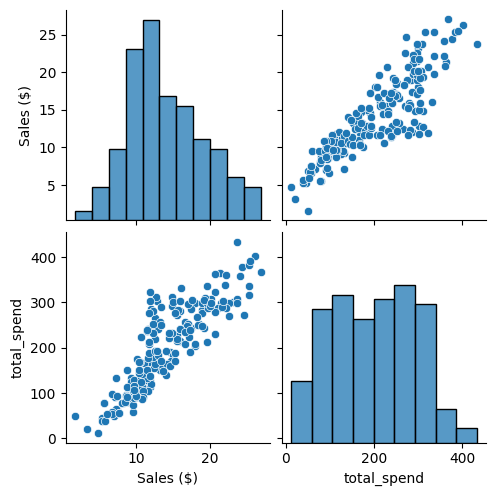

In [9]:
sns.pairplot(df_n)
plt.show()

In [10]:
df_n.corr()

,Sales ($),total_spend
Sales ($),1.000000,0.867712
total_spend,0.867712,1.000000


##Data Wrangling
- no encoding is required

In [11]:
##Train-Test Split
x=df_n.drop(columns='Sales ($)')
y=df_n['Sales ($)']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Modelling 1: SLR
- Modelling with default parameters
- The base model for evaluation of this dataset was SLR

In [12]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print(model.intercept_)
print(model.coef_)

4.1695120134890455
[0.0489571]


In [13]:
# Predictions
train_predictions=model.predict(x_train)

In [14]:
test_predictions=model.predict(x_test)

In [15]:
# Evaluation
from sklearn.metrics import mean_squared_error
print('MSE for test data: ',mean_squared_error(y_test,test_predictions))
print('MSE for train data: ',mean_squared_error(y_train,train_predictions))

MSE for test data:  7.779806406885763
MSE for train data:  6.421575106597047


In [16]:
print('RMSE for test data: ',np.sqrt(mean_squared_error(y_test,test_predictions)))
print('RMSE for train data: ',np.sqrt(mean_squared_error(y_train,train_predictions)))

RMSE for test data:  2.789230432733331
RMSE for train data:  2.5340826952956856


In [17]:
from sklearn.metrics import r2_score
print('R2 for test data: ',r2_score(y_test,test_predictions))
print('R2 for train data: ',r2_score(y_train,train_predictions))

R2 for test data:  0.7535196255373879
R2 for train data:  0.7524092686260717


In [18]:
model.score(x_test,y_test)

0.7535196255373879

In [19]:
model.score(x_train,y_train)

0.7524092686260717

# Checklist
- For any Supervised Machine Learning Algorithm (Other than Linear Regression)
    1. Check whether model has overfitting or underfitting problem
    2. Is Test Accuracy = Cross validation Score
    4. Check model meets the business problem requirements
    5. Finally, save the model and share to the deployment team
- For Linear Regression, in addition we have to
- Check Assumptions (if it is Linear Regression)

In [20]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)

cv_score=scores.mean()
print('Cross Validation Score: ', cv_score)

[0.74964192 0.79455226 0.76417134 0.74872042 0.65980565]
Cross Validation Score:  0.743378317855542


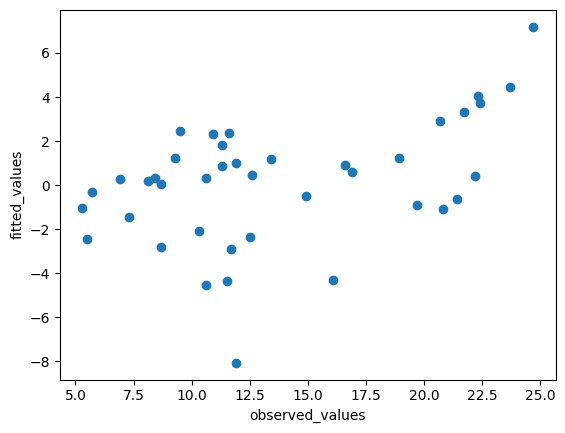

In [21]:
# Check for assumptions
## Linearity of Errors
test_res=y_test-test_predictions
plt.scatter(y_test,test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

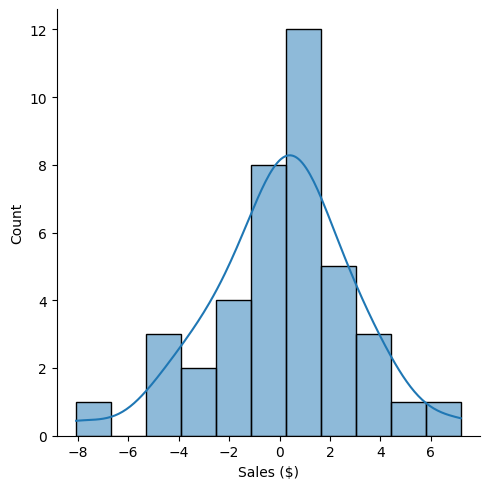

In [22]:
## Normality of Errors
sns.displot(test_res,kde=True)
plt.show()


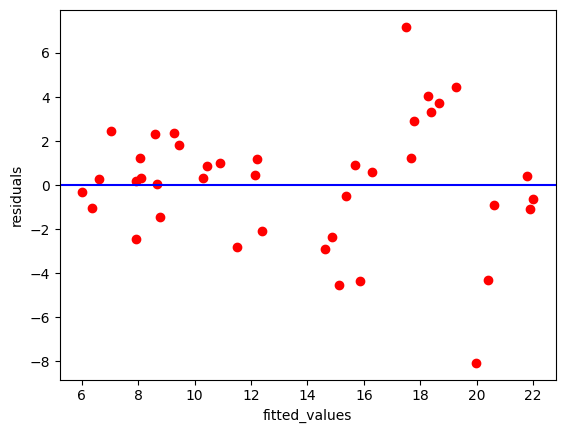

In [23]:
## Equal variance of errors(Homoscadesicity)
plt.scatter(test_predictions,test_res,c='r')
plt.axhline(y=0,color='blue')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

In [24]:
## variables significance
import statsmodels.formula.api as smf
model2=smf.ols('y~x',data=df).fit()
model2.summary()

#null hypothesis indicates thah avg is the best fit line
#alternate hypothsis indicates that regression line is the best fit line

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     603.4
Date:                Mon, 13 Nov 2023   Prob (F-statistic):           5.06e-62
Time:                        22:13:16   Log-Likelihood:                -473.88
No. Observations:                 200   AIC:                             951.8
Df Residuals:                     198   BIC:                             958.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2430      0.439      9.676      0.000       3.378       5.108
x              0.0487      0.002     24.564      0.000       0.045       0.053
==============================================================================
Omnibus:                        6.851   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.033   Jarque-Bera (JB):                6.692
Skew:                          -0.373   Prob(JB):                       0.0352
Kurtosis:                       3.495   Cond. No.                         528.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Modelling 2: MLR

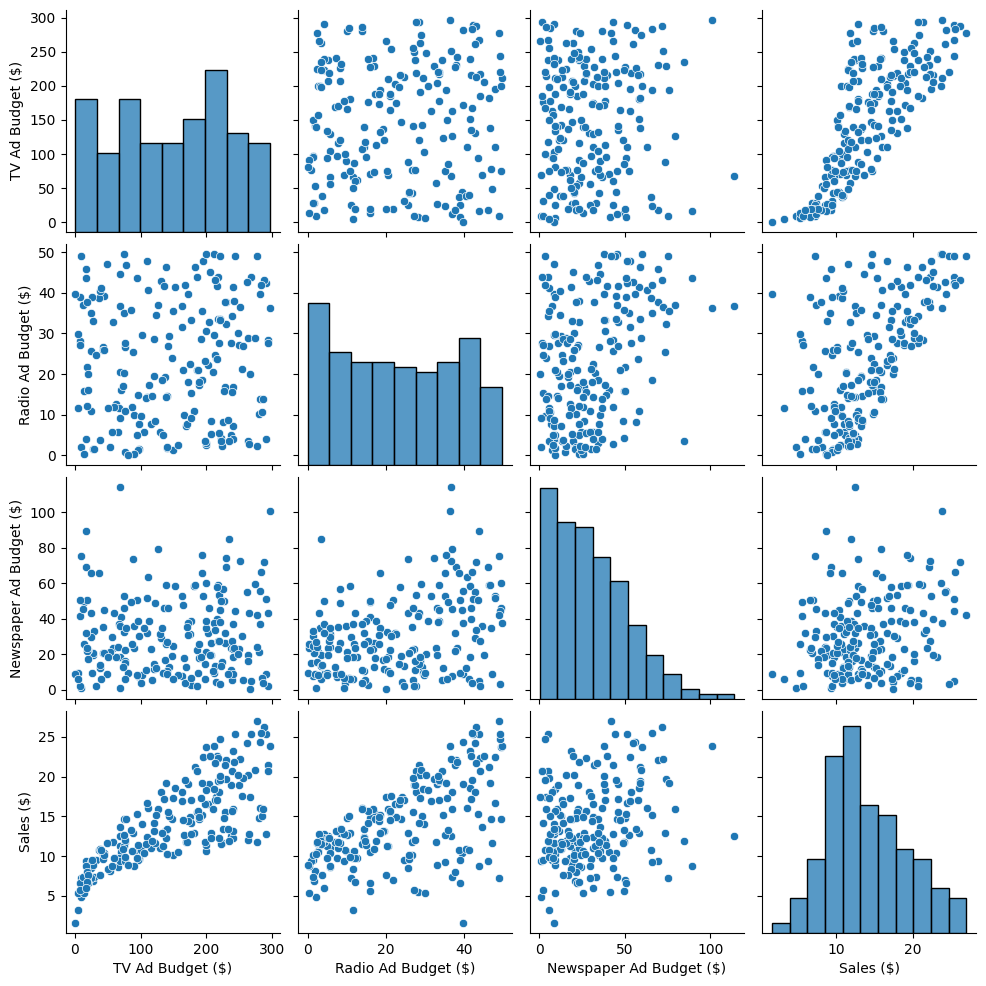

In [25]:
df_ml = df.drop(columns='Unnamed: 0')
sns.pairplot(df_ml)
plt.show()

In [26]:
df_ml.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [27]:
df_ml.corr()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
TV Ad Budget ($),1.000000,0.054809,0.056648,0.782224
Radio Ad Budget ($),0.054809,1.000000,0.354104,0.576223
Newspaper Ad Budget ($),0.056648,0.354104,1.000000,0.228299
Sales ($),0.782224,0.576223,0.228299,1.000000


- The relationship between y and x should be high
- the higher the value the stronger the correlation
- the relation between any two independent variables should be low
- If the relationship between any two independent variables is strong, it is  colinarity problem

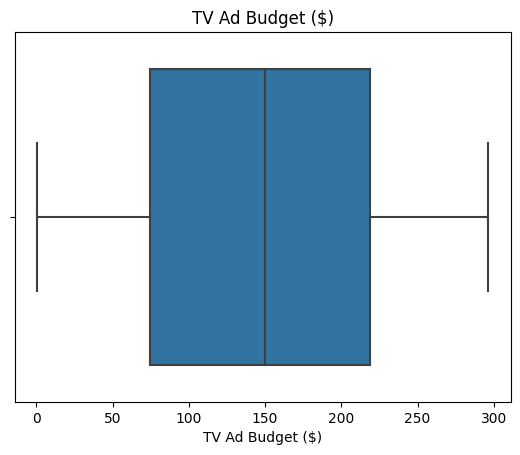

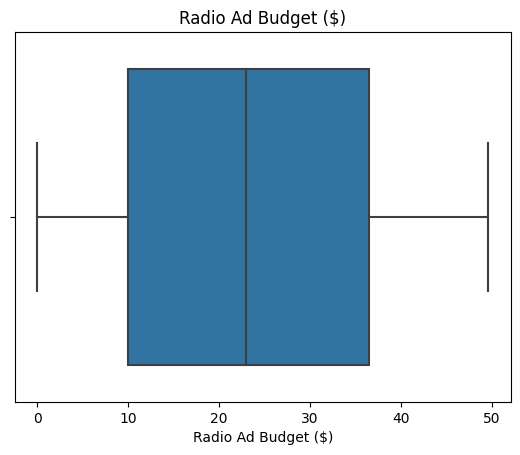

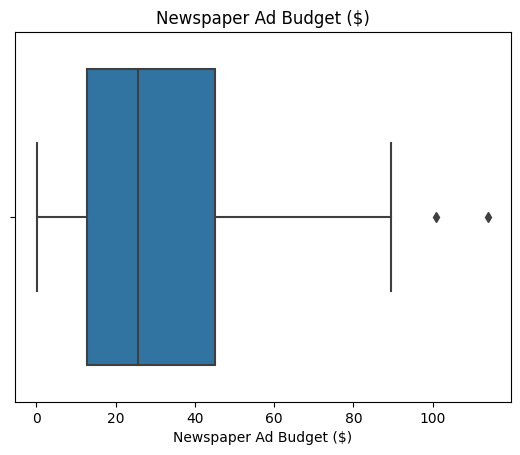

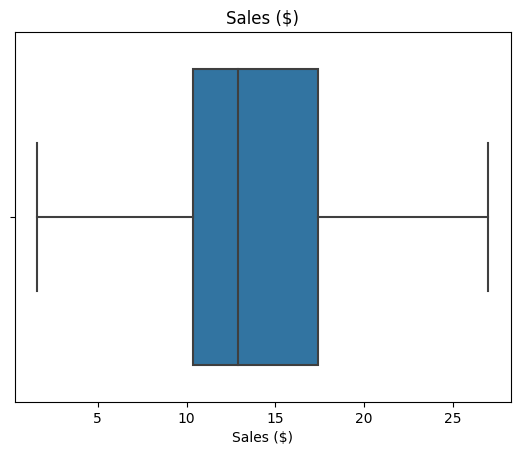

In [28]:
# Treating for outliers
import seaborn as sns
import matplotlib.pyplot as plt

for column in df_ml.columns:
    sns.boxplot(x=df_ml[column])  # Specify x as a keyword argument
    plt.title(column)
    plt.show()

In [29]:
pip install feature_engine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.9/328.9 kB 5.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [30]:
from feature_engine.outliers import Winsorizer
df_ml["Newspaper Ad Budget ($)"].fillna(df_ml["Newspaper Ad Budget ($)"].median(),inplace=True)
win=Winsorizer(capping_method='iqr',tail='both',fold=1.5)
df_ml["Newspaper Ad Budget ($)"]=win.fit_transform(df_ml[["Newspaper Ad Budget ($)"]])
df_ml

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [31]:
print(win.left_tail_caps_,win.right_tail_caps_)

{'Newspaper Ad Budget ($)': -35.775000000000006} {'Newspaper Ad Budget ($)': 93.625}


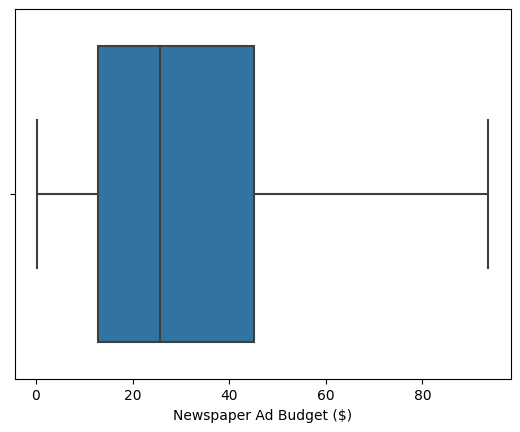

In [32]:
sns.boxplot(x=df_ml["Newspaper Ad Budget ($)"])
plt.show()

In [33]:
## Train-Test Split
x=df_ml.drop(columns='Sales ($)')
y=df_ml['Sales ($)']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42) 

## Modelling
Multiple Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [35]:
print(model.intercept_)
print(model.coef_)

2.7070118464367745
[0.04406616 0.19928692 0.00692299]


In [36]:
# Predictions
train_predictions=model.predict(x_train)
test_predictions=model.predict(x_test)

In [37]:
# Evaluation Metrics
from sklearn.metrics import mean_squared_error
test_RMSE=np.sqrt(mean_squared_error(y_test,test_predictions))
train_RMSE=np.sqrt(mean_squared_error(y_train,train_predictions))
print(train_RMSE,test_RMSE)


1.5746256091552053 1.9472864778494814


In [38]:
from sklearn.metrics import r2_score
print('R2 for test data',r2_score(y_test,test_predictions))
print('R2 for train data',r2_score(y_train,train_predictions))

R2 for test data 0.8611251045785456
R2 for train data 0.9055124964622552


In [39]:
model.score(x_train,y_train)
model.score(x_test,y_test)

0.8611251045785456

In [40]:
model.score(x_train,y_train)

0.9055124964622552

In [41]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)
scores.mean()

[0.87874518 0.9175936  0.92932012 0.81431801 0.89547377]


0.8870901371762117

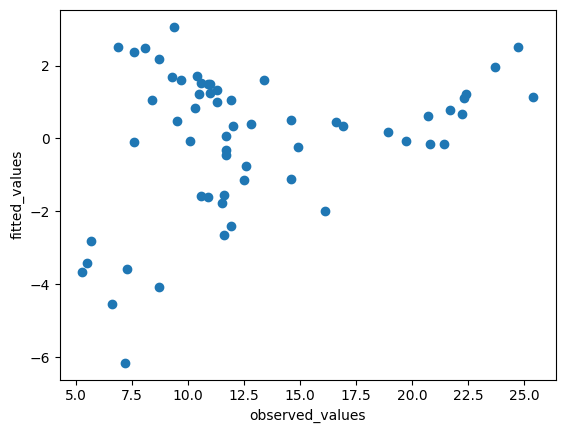

In [42]:
# Check for assumptions
# Linearity of Errors
test_res=y_test-test_predictions
plt.scatter(y_test,test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

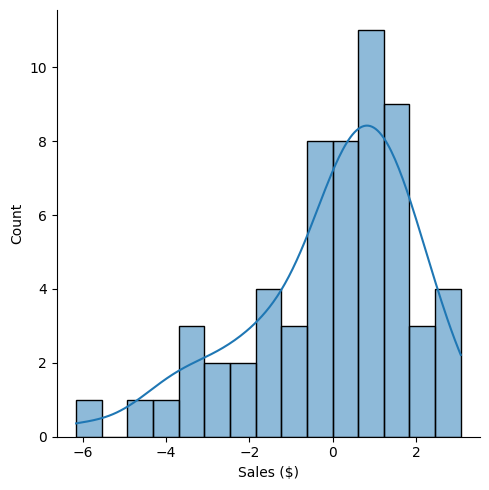

In [43]:
# Normality of Errors
sns.displot(test_res,bins=15,kde=True)
plt.show()

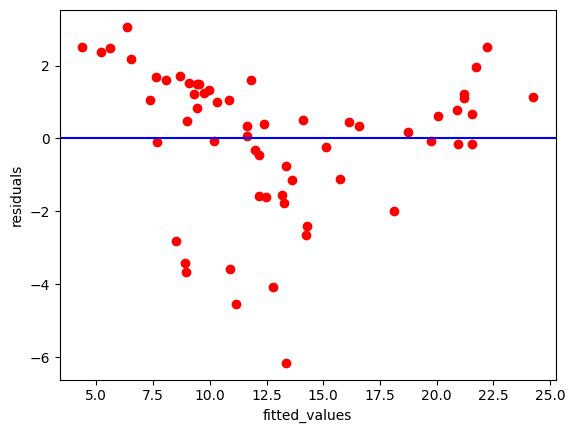

In [44]:
# Equal Varience of Errors(Homoscadesicity)
plt.scatter(test_predictions,test_res,c='r')
plt.axhline(y=0,color='blue')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

Variables Significance
- Hypothesis Testing for variables:
    * Null Hypothesis: Theres no relationship between input variable (and thus beta1 equal 0)
    * Alternate Hypothesis: Theres relationship between input variable (and thus beta1 is not equal 0)

In [45]:
import statsmodels.formula.api as smf
model1=smf.ols('y~x',data=df_ml).fit()
model1.summary()
#null hypothesis indicates thah avg is the best fit line, p<0.05
#alternate hypothsis indicates that regression line is the best fit line, p>0.05

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 13 Nov 2023   Prob (F-statistic):           1.58e-96
Time:                        22:13:42   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9387      0.313      9.400      0.000       2.322       3.555
x[0]           0.0458      0.001     32.805      0.000       0.043       0.049
x[1]           0.1885      0.009     21.876      0.000       0.172       0.206
x[2]          -0.0010      0.006     -0.171      0.864      -0.013       0.011
==============================================================================
Omnibus:                       60.392   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.131
Skew:                          -1.327   Prob(JB):                     1.52e-33
Kurtosis:                       6.330   Cond. No.                         455.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

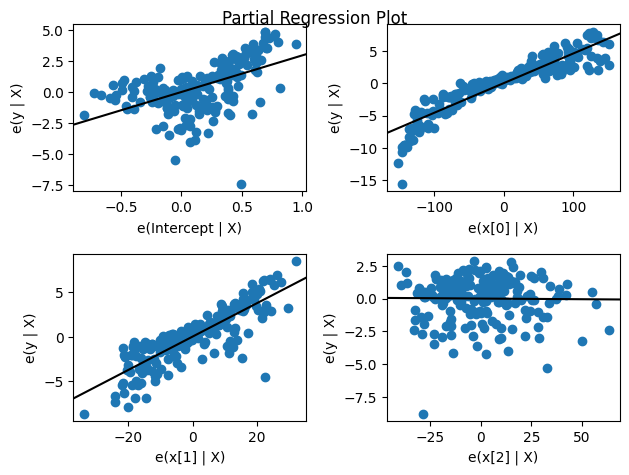

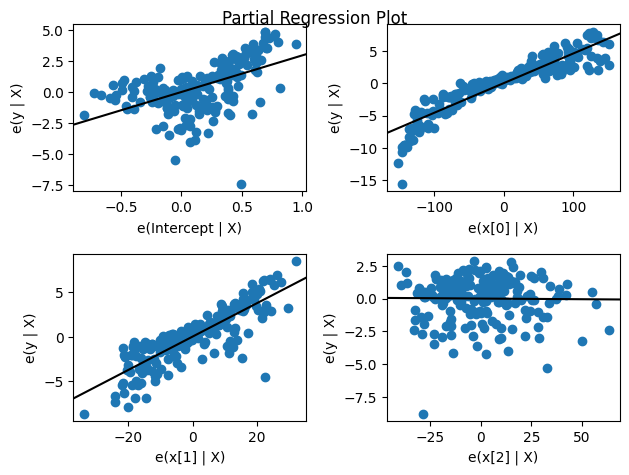

In [46]:
import statsmodels.api as sm
sm.graphics.plot_partregress_grid(model1)

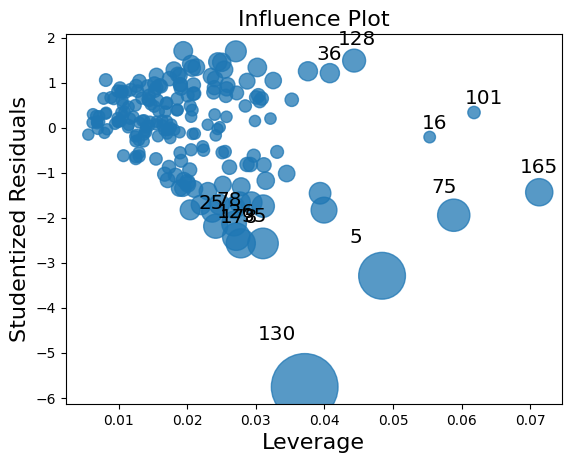

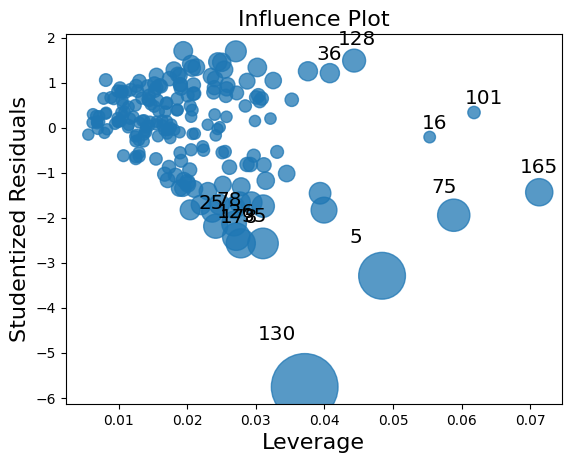

In [47]:
import statsmodels.api as sm
sm.graphics.influence_plot(model1)

In [48]:
df_ml=df_ml.drop(df_ml.index[[130,5,75,165]],axis=0)
df_ml

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [49]:
df_ml = df_ml.rename(columns={
    'TV Ad Budget': 'TVAdBudget',
    'Radio Ad Budget': 'RadioAdBudget',
    'Newspaper Ad Budget': 'NewspaperAdBudget'
})
df_ml = df_ml.rename(columns={'Sales ($)': 'Sales'})
df_ml = df_ml.rename(columns={'Newspaper Ad Budget ($)': 'NewspaperAdBudget'})
df_ml = df_ml.rename(columns={'TV Ad Budget ($)': 'TVAdBudget'})
df_ml = df_ml.rename(columns={'Radio Ad Budget ($)': 'RadioAdBudget'})

In [50]:
lm=smf.ols(formula='Sales~TVAdBudget+RadioAdBudget+NewspaperAdBudget',data=df_ml).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     713.4
Date:                Mon, 13 Nov 2023   Prob (F-statistic):          8.28e-104
Time:                        22:13:46   Log-Likelihood:                -354.29
No. Observations:                 196   AIC:                             716.6
Df Residuals:                     192   BIC:                             729.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.0543      0.278     10.988      0.000       2.506       3.603
TVAdBudget            0.0440      0.001     34.707      0.000       0.041       0.046
RadioAdBudget         0.1950      0.008     24.907      0.000       0.180       0.210
NewspaperAdBudget     0.0024      0.006      0.432      0.666      -0.009       0.014
==============================================================================
Omnibus:                       17.180   Durbin-Watson:                   2.169
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.326
Skew:                          -0.762   Prob(JB):                     6.36e-05
Kurtosis:                       3.204   Cond. No.                         456.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Variance Inflation Factor
-VIF measures the ratio between the variance for a given regression coefficient with only that variable in model versus the variance for a given regression coefficient with all the variables in the model

In [51]:
rsq_TV=smf.ols('TVAdBudget~RadioAdBudget+NewspaperAdBudget',data=df_ml).fit()
rsq_TV.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             TVAdBudget   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.211
Date:                Mon, 13 Nov 2023   Prob (F-statistic):              0.300
Time:                        22:13:46   Log-Likelihood:                -1146.6
No. Observations:                 196   AIC:                             2299.
Df Residuals:                     193   BIC:                             2309.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           131.4989     12.643     10.401      0.000     106.563     156.435
RadioAdBudget         0.4661      0.443      1.051      0.295      -0.409       1.341
NewspaperAdBudget     0.2178      0.319      0.683      0.496      -0.411       0.847
==============================================================================
Omnibus:                       74.639   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               11.360
Skew:                          -0.090   Prob(JB):                      0.00341
Kurtosis:                       1.834   Cond. No.                         90.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
rsq_radio=smf.ols('RadioAdBudget~TVAdBudget+NewspaperAdBudget',data=df_ml).fit()
rsq_radio.summary()
# we see how much one variable effects the other variables..we can check for r2 values - high r2 idicates high correlation

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          RadioAdBudget   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     15.63
Date:                Mon, 13 Nov 2023   Prob (F-statistic):           5.12e-07
Time:                        22:13:46   Log-Likelihood:                -789.68
No. Observations:                 196   AIC:                             1585.
Df Residuals:                     193   BIC:                             1595.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            13.5173      2.364      5.718      0.000       8.855      18.180
TVAdBudget            0.0122      0.012      1.051      0.295      -0.011       0.035
NewspaperAdBudget     0.2595      0.048      5.386      0.000       0.165       0.355
==============================================================================
Omnibus:                       24.366   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                8.061
Skew:                           0.187   Prob(JB):                       0.0178
Kurtosis:                       2.079   Cond. No.                         418.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [53]:
rsq_newspaper=smf.ols('NewspaperAdBudget~TVAdBudget+RadioAdBudget',data=df_ml).fit()
rsq_newspaper.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      NewspaperAdBudget   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     15.26
Date:                Mon, 13 Nov 2023   Prob (F-statistic):           7.04e-07
Time:                        22:13:46   Log-Likelihood:                -854.61
No. Observations:                 196   AIC:                             1715.
Df Residuals:                     193   BIC:                             1725.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        16.4713      3.357      4.906      0.000       9.850      23.092
TVAdBudget        0.0111      0.016      0.683      0.496      -0.021       0.043
RadioAdBudget     0.5035      0.093      5.386      0.000       0.319       0.688
==============================================================================
Omnibus:                        3.781   Durbin-Watson:                   1.865
Prob(Omnibus):                  0.151   Jarque-Bera (JB):                3.820
Skew:                           0.335   Prob(JB):                        0.148
Kurtosis:                       2.859   Cond. No.                         424.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
rsq_TV=smf.ols('TVAdBudget~RadioAdBudget+NewspaperAdBudget',data=df_ml).fit().rsquared
vif_TV=1/(1-rsq_TV)
rsq_radio=smf.ols('RadioAdBudget~TVAdBudget+NewspaperAdBudget',data=df_ml).fit().rsquared
vif_radio=1/(1-rsq_radio)
rsq_newspaper=smf.ols('NewspaperAdBudget~RadioAdBudget+TVAdBudget',data=df_ml).fit().rsquared
vif_newspaper=1/(1-rsq_newspaper)

In [55]:
d1={'Variables':['TVAdBudget','RadioAdBudget','NewspaperAdBudget'],'VIF':[vif_TV,vif_radio,vif_newspaper]}
Vif_frame=pd.DataFrame(d1)
Vif_frame

,Variables,VIF
0,TVAdBudget,1.012553
1,RadioAdBudget,1.161954
2,NewspaperAdBudget,1.158133


In [56]:
#if the vif>4 - then that variable is effecting the other variable
#if the vif<4 - then we can drop that variable

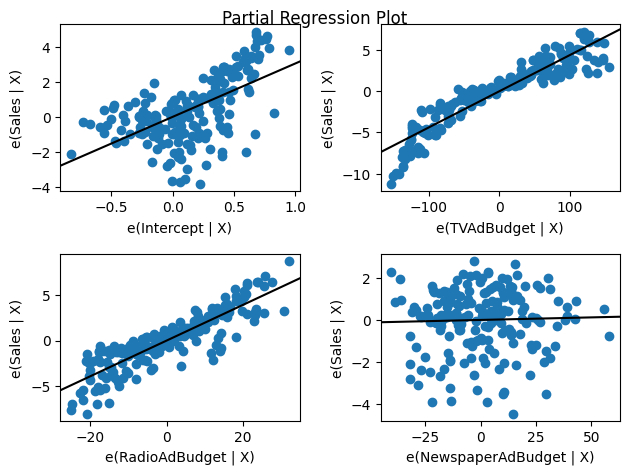

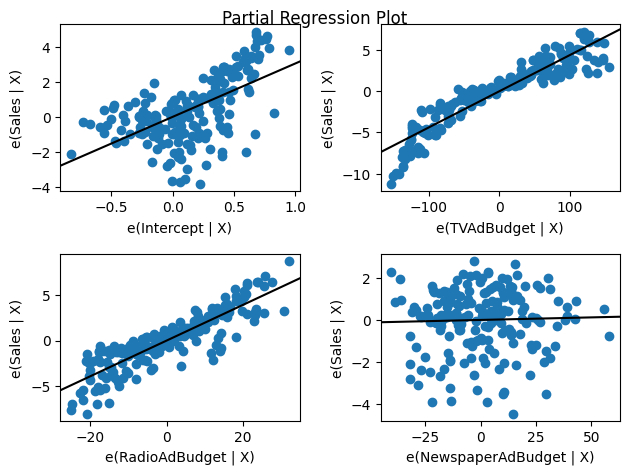

In [57]:
#Added variable plot(AV plot)
# Partial differentiation instead of normal distribution
sm.graphics.plot_partregress_grid(lm)

- Added variable is not showing any significance for newspaper
### Final Model including TV and Radio only

In [58]:
x=df_ml[['TVAdBudget','RadioAdBudget']]
y=df_ml['Sales']

In [59]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
model.intercept_
model.coef_
train_predictions=model.predict(x_train)
test_predictions=model.predict(x_test)

In [60]:
from sklearn.metrics import mean_squared_error
test_RMSE=np.sqrt(mean_squared_error(y_test,test_predictions))
train_RMSE=np.sqrt(mean_squared_error(y_train,train_predictions))
print(train_RMSE,test_RMSE)
model.score(x_train,y_train)
model.score(x_test,y_test)

1.44339505179268 1.5874057417789977


0.893310787449154

In [61]:
model.score(x_train,y_train)

0.924372471757504

In [62]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)
scores.mean()

[0.90732874 0.92718157 0.93879211 0.87301065 0.91327498]


0.9119176098240158

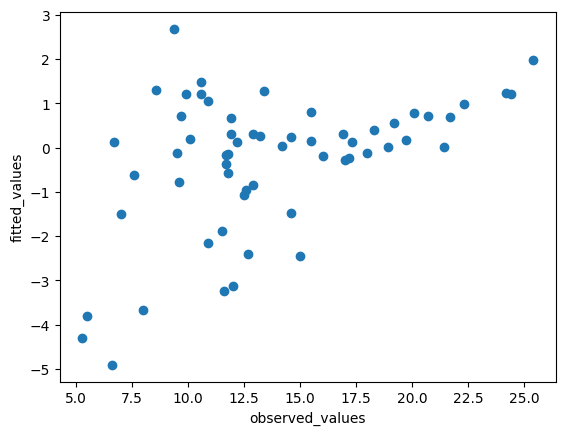

In [63]:
test_res=y_test-test_predictions
plt.scatter(y_test,test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

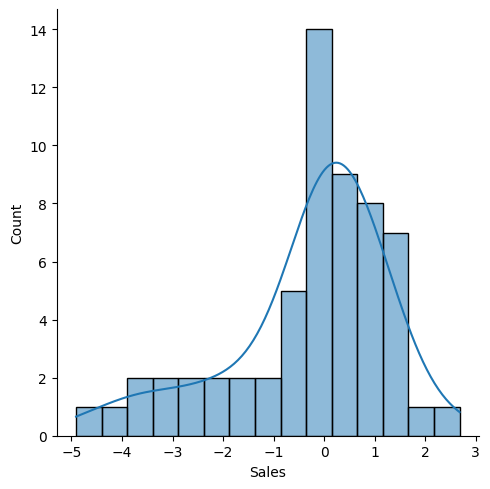

In [64]:
sns.displot(test_res,bins=15,kde=True)
plt.show()

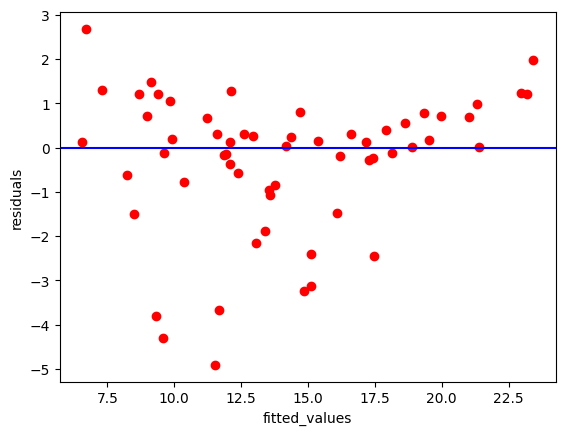

In [65]:
plt.scatter(test_predictions,test_res,c='r')
plt.axhline(y=0,color='blue')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

In [66]:
final_model=smf.ols(formula='Sales~TVAdBudget+RadioAdBudget',data=df_ml).fit()
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     1075.
Date:                Mon, 13 Nov 2023   Prob (F-statistic):          2.45e-105
Time:                        22:13:50   Log-Likelihood:                -354.39
No. Observations:                 196   AIC:                             714.8
Df Residuals:                     193   BIC:                             724.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.0943      0.262     11.830      0.000       2.578       3.610
TVAdBudget        0.0440      0.001     34.843      0.000       0.042       0.046
RadioAdBudget     0.1962      0.007     26.938      0.000       0.182       0.211
==============================================================================
Omnibus:                       17.277   Durbin-Watson:                   2.174
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.453
Skew:                          -0.765   Prob(JB):                     5.97e-05
Kurtosis:                       3.207   Cond. No.                         424.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Modelling - Polynomial Regression
- Modelling with default parameters
- The base model for evaluation of this dataset was polynomial regression

In [67]:
X=df_ml[['TVAdBudget','RadioAdBudget','NewspaperAdBudget']]
y=df_ml['Sales']

In [68]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [69]:
#transform original data set by adding polynomial features by increasing its degree to 2
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
x_train=pd.DataFrame(polynomial_converter.fit_transform(x_train))
x_test=pd.DataFrame(polynomial_converter.transform(x_test))

In [70]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [71]:
print(model.intercept_)
print(model.coef_)

5.19553336095751
[ 0.0491083   0.03665824 -0.00010034  0.0010038   0.00028623]


In [72]:
# Predictions
train_pred=model.predict(x_train)
test_pred=model.predict(x_test)

In [73]:
# Evaluation
model.score(x_train,y_train)
model.score(x_test,y_test)

0.9877781519563397

In [74]:
model.score(x_train,y_train)

0.9917250205836133

In [75]:
# Comparision with Linear Regression
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=3,include_bias=False)
x_poly=polynomial_converter.fit_transform(x)
x_poly=pd.DataFrame(x_poly)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_poly, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

train_pred=model.predict(x_train)
test_pred=model.predict(x_test)

print(model.score(x_train,y_train))
print(model.score(x_test,y_test))

0.9949159161607737
0.9926160483510366


In [76]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x_poly,y,cv=5)
print(scores)
scores.mean()

[0.99347267 0.99302333 0.99349243 0.99024702 0.9974498 ]


0.9935370514924923

In [77]:
# Hyperparameter Tuning
train_r2=[]
test_r2=[]
for i in range(1,10):
    from sklearn.preprocessing import PolynomialFeatures
    polynomial_converter=PolynomialFeatures(degree=i,include_bias=False)
    x_poly=polynomial_converter.fit_transform(x)
    x_ply=pd.DataFrame(x_poly)
    
    from sklearn.model_selection import train_test_split
    x_train,x_test,y_train,Y_test=train_test_split(x_poly,y,test_size=0.3,random_state=42)
    
    from sklearn.linear_model import LinearRegression
    model=LinearRegression()
    model.fit(x_train,y_train)
    
    test_pred=model.predict(x_train)
    test_pred=model.predict(x_test)
    
    train_r2.append(model.score(x_train,y_train))
    test_r2.append(model.score(x_test,y_test))

In [78]:
train_r2

[0.924372471757504,
 0.9917250205836133,
 0.9949159161607737,
 0.9963476801149452,
 0.9972460961785118,
 0.9977708625555661,
 -4.02089496471764,
 -0.025538599437912035,
 0.8756578750569483]

In [79]:
test_r2

[0.893310787449154,
 0.9877781519563397,
 0.9926160483510366,
 0.993405546045268,
 0.9932866399829412,
 0.9935611643409061,
 -5.159022366087711,
 -0.03926910812889717,
 0.7946960596087322]

- degree = 2 is the best fit

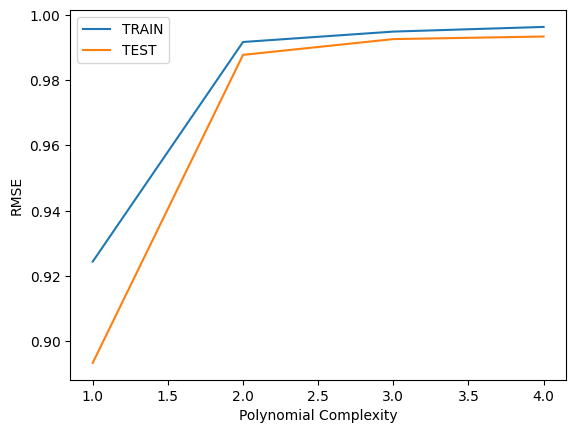

In [80]:
plt.plot(range(1,5),train_r2[:4],label='TRAIN')
plt.plot(range(1,5),test_r2[:4],label='TEST')
plt.xlabel('Polynomial Complexity')
plt.ylabel("RMSE")
plt.legend()
plt.show()

In [81]:
#Rebuilding the model with best parameters
final_poly_converter=PolynomialFeatures(degree=2,include_bias=False)
x_poly=final_poly_converter.fit_transform(x)

x_train, x_test, y_train, y_test=train_test_split(x_poly,y,test_size=0.3,random_state=42)

final_model=LinearRegression()
final_model.fit(x_train,y_train)

train_pred=final_model.predict(x_train)
test_pred=final_model.predict(x_test)

print('Train R2:',final_model.score(x_train,y_train))
print('Test R2:',final_model.score(x_test,y_test))

Train R2: 0.9917250205836133
Test R2: 0.9877781519563397


## Modelling - Regularization
- Modelling with default parameters
- The base model for evaluation of this dataset was Regularization-Lasso,Ridge,ElasticNet Regression 

In [82]:
x=df_ml[['TVAdBudget','RadioAdBudget','NewspaperAdBudget']]
y=df_ml['Sales']

In [83]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

### Modelling - Lasso Regression
Modelling with default parameters

In [84]:
from sklearn.linear_model import Lasso
lasso_base=Lasso()
lasso_base.fit(x_train,y_train)
print('Intercept: ',lasso_base.intercept_)
print('coefficients: ',lasso_base.coef_)

Intercept:  3.4078595909256553
coefficients:  [0.04211923 0.19649362 0.00160321]


In [85]:
test_predictions=lasso_base.predict(x_test)
train_predictions=lasso_base.predict(x_train)

In [86]:
print(lasso_base.score(x_train,y_train))
print(lasso_base.score(x_test,y_test))
from sklearn.model_selection import cross_val_score
scores=cross_val_score(lasso_base,x,y,cv=5)
print(scores.mean())

0.9243038807306678
0.8944039390588986
0.9114498100084646


In [87]:
## Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
estimator=Lasso()
param_grid={'alpha':[0.1,0.2,0.5,0.7,1,2,5,10,100,1000]}

In [88]:
model_hp=GridSearchCV(estimator,param_grid,cv=5,scoring='r2')
model_hp.fit(x_train,y_train)
model_hp.best_params_

{'alpha': 0.1}

In [89]:
## Rebuilt Lasso Model using best hyperparameters
from sklearn.linear_model import Lasso
lasso_best=Lasso(alpha=0.1)
lasso_best.fit(x_train,y_train)

print('Intercept: ',lasso_base.intercept_)
print('coefficients: ',lasso_base.coef_)

test_predictions=lasso_base.predict(x_test)
train_predictions=lasso_base.predict(x_train)
print(lasso_base.score(x_train,y_train))
print(lasso_base.score(x_test,y_test))
from sklearn.model_selection import cross_val_score
scores=cross_val_score(lasso_base,x,y,cv=5)
print(scores.mean())

Intercept:  3.4078595909256553
coefficients:  [0.04211923 0.19649362 0.00160321]
0.9243038807306678
0.8944039390588986
0.9114498100084646


# Ridge Regression
- Modeling with default parameters

In [90]:
from sklearn.linear_model import Ridge
ridge_model=Ridge()
ridge_model.fit(x_train,y_train)

train_predictions=ridge_model.predict(x_train)
test_predictions=ridge_model.predict(x_test)

from sklearn.metrics import mean_squared_error
train_rmse=np.sqrt(mean_squared_error(y_test,test_predictions))
test_rmse=np.sqrt(mean_squared_error(y_train,train_predictions))

print('train RMSE:',train_rmse)
print('test RMSE:',test_rmse)

train RMSE: 1.5864479896899806
test RMSE: 1.4423266069657357


## Hyperparameter Tuning
### Identifying the best alpha value for Ridge Regression

In [91]:
from sklearn.model_selection import GridSearchCV
estimator=Ridge()
param_grid={'alpha':list(range(1,11))}
model_hp=GridSearchCV(estimator,param_grid,cv=5)
model_hp.fit(x_train,y_train)
model_hp.best_params_

{'alpha': 1}

In [92]:
## Rebuilt Ridge Model using best hyperparameters
from sklearn.linear_model import Ridge
ridge_model=Ridge( alpha=1)
ridge_model.fit(x_train,y_train)

train_predictions=ridge_model.predict(x_train)
test_predictions=ridge_model.predict(x_test)

from sklearn.metrics import mean_squared_error
train_rmse=np.sqrt(mean_squared_error(y_test,test_predictions))
test_rmse=np.sqrt(mean_squared_error(y_train,train_predictions))

print('train RMSE:',train_rmse)
print('test RMSE:',test_rmse)

train RMSE: 1.5864479896899806
test RMSE: 1.4423266069657357


# Elasticnet Regression
Modeling with default parameters

In [93]:
from sklearn.linear_model import ElasticNet
enr_model=ElasticNet()
enr_model.fit(x_train,y_train)

test_predictions=enr_model.predict(x_test)
train_predictions=enr_model.predict(x_train)

from sklearn.metrics import mean_squared_error
train_rmse=np.sqrt(mean_squared_error(y_test,test_predictions))
test_rmse=np.sqrt(mean_squared_error(y_train,train_predictions))

print('train RMSE:',train_rmse)
print('test RMSE:',test_rmse)

train RMSE: 1.5815096107855353
test RMSE: 1.4428997892623618


In [94]:
## Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
estimator=ElasticNet()
param_grid={'alpha':[0.1,0.2,1,2,3,5,10],
            'l1_ratio':[0.1,0.5,0.75,0.9,0.95,1]}
enr_hp=GridSearchCV(estimator,param_grid,cv=5)
enr_hp.fit(x_train,y_train)
enr_hp.best_params_

{'alpha': 0.1, 'l1_ratio': 0.1}

In [95]:
from sklearn.linear_model import ElasticNet
enr_model=ElasticNet(alpha=0.1,l1_ratio= 0.1)
enr_model.fit(x_train,y_train)

test_predictions=enr_model.predict(x_test)
train_predictions=enr_model.predict(x_train)

from sklearn.metrics import mean_squared_error
train_rmse=np.sqrt(mean_squared_error(y_test,test_predictions))
test_rmse=np.sqrt(mean_squared_error(y_train,train_predictions))

print('train RMSE:',train_rmse)
print('test RMSE:',test_rmse)

train RMSE: 1.5861737990101783
test RMSE: 1.4423278027781832


# Final references:
Polynomial Regression is the best fit model with test accuracy of 0.98 and Cross validation score of 0.98 